In [1]:
import numpy as np

T1 = np.ones((50, 50))
T2 = np.ones((50, 50))
alpha = 1
f0 = 1
field_map = np.zeros((50, 50))
M0 = np.ones((50, 50))
phi = 0
inputs = [T1, T2, alpha, f0, -field_map, M0, phi]
broadcast_shape = np.broadcast(*inputs).shape
print(broadcast_shape)

(50, 50)


In [1]:
from pathlib import Path
import os

path = 'D:\DeepSSFP\SavedModels'
path = path.split(os.sep)
path = Path(os.path.join(*path))
print(path)



D:DeepSSFP\SavedModels


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

def perlin_2d(size, width, height):
    ''' Generates perlin noise specified width and height. Octave used to set size of noise features. '''

    size = float(size)
    width = int(width)
    height = int(height)    
    seed = random.randint(1, 1000)
    X = np.linspace(0, size, width, endpoint=False)
    Y = np.linspace(0, size, height, endpoint=False)
    x, y = np.meshgrid(X, Y)  
    noise = perlin(x, y, seed=seed)
    return noise

def perlin(x, y, seed=0):
    ''' Generated perlin noise for a (x,y) point '''
    # Taken from https://stackoverflow.com/questions/42147776/producing-2d-perlin-noise-with-numpy
    # For tutorial on perlin noise: https://iq.opengenus.org/perlin-noise/
    # For tutorial on perlin noise: https://gpfault.net/posts/perlin-noise.txt.html

    # permutation table
    np.random.seed(seed)
    p = np.arange(256, dtype=int)
    np.random.shuffle(p)
    p = np.stack([p, p]).flatten()
    # coordinates of the top-left
    xi, yi = x.astype(int), y.astype(int)
    # internal coordinates
    xf, yf = x - xi, y - yi
    # fade factors
    u, v = fade(xf), fade(yf)
    # noise components
    n00 = gradient(p[p[xi] + yi], xf, yf)
    n01 = gradient(p[p[xi] + yi + 1], xf, yf - 1)
    n11 = gradient(p[p[xi + 1] + yi + 1], xf - 1, yf - 1)
    n10 = gradient(p[p[xi + 1] + yi], xf - 1, yf)
    # combine noises
    x1 = lerp(n00, n10, u)
    x2 = lerp(n01, n11, u)  # FIX1: I was using n10 instead of n01
    return lerp(x1, x2, v)  # FIX2: I also had to reverse x1 and x2 here

def lerp(a, b, x):
    "linear interpolation"
    return a + x * (b - a)

def fade(t):
    "6t^5 - 15t^4 + 10t^3"
    return 6 * t**5 - 15 * t**4 + 10 * t**3

def gradient(h, x, y):
    "grad converts h to the right gradient vector and return the dot product with (x,y)"
    vectors = np.array([[0, 1], [0, -1], [1, 0], [-1, 0]])
    g = vectors[h % 4]
    return g[:, :, 0] * x + g[:, :, 1] * y

(256, 256, 4)


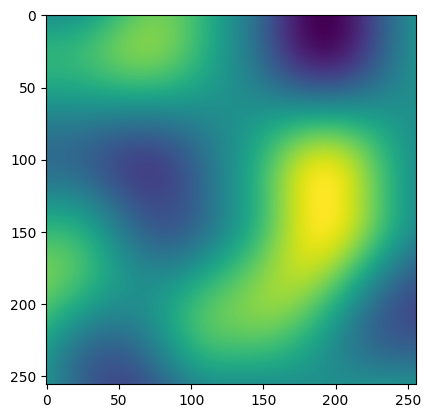

In [11]:
n = perlin_2d(2, 256, 256)
print(n.shape)
plt.imshow(n[:,:,0])
plt.show()